In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
files = {"T50": "Synth_Spectros_T50_N1.xlsx", 
            "T60": "Synth_Spectros_T60_N1.xlsx", 
            "T70": "Synth_Spectros_T70_N1.xlsx"}
pattern = r"^I\d+_P\d+_T\d+_HR\d+$"
im_data_by_temp = {t: {n: pd.read_excel(p, sheet_name=n) for n in pd.ExcelFile(p).sheet_names 
                                      if re.match(pattern, n)}  for t, p in files.items()}

In [3]:
for temp, path in files.items():
    sheets = pd.ExcelFile(path).sheet_names
    print(f"{temp} ({path}): {sheets}")

T50 (Synth_Spectros_T50_N1.xlsx): ['I10_P300_T50_HR50', 'I10_P400_T50_HR50', 'I10_P500_T50_HR50', 'I20_P300_T50_HR50', 'I20_P400_T50_HR50', 'I20_P500_T50_HR50', 'I30_P300_T50_HR50', 'I30_P400_T50_HR50', 'I30_P500_T50_HR50', 'I35_P300_T50_HR50', 'I35_P400_T50_HR50', 'I35_P500_T50_HR50', 'I40_P300_T50_HR50', 'I40_P400_T50_HR50', 'I40_P500_T50_HR50', 'I45_P300_T50_HR50', 'I45_P400_T50_HR50', 'I45_P500_T50_HR50', 'I50_P300_T50_HR50', 'I50_P400_T50_HR50', 'I50_P500_T50_HR50', 'I20_P300_T50_HRLOW_TBH2_20', 'I20_P300_T50_HRLOW_TBH2_40', 'I20_P300_T50_HRLOW_TBH2_65', 'I10_P300_T50_HR0', 'I20_P300_T50_HR0', 'I30_P300_T50_HR0', 'I35_P300_T50_HR0', 'I40_P300_T50_HR0', 'I45_P300_T50_HR0', 'I50_P300_T50_HR0', 'SYNTH', 'TRACES']
T60 (Synth_Spectros_T60_N1.xlsx): ['I10_P300_T60_HR50', 'I10_P400_T60_HR50', 'I10_P500_T60_HR50', 'I20_P300_T60_HR50', 'I20_P400_T60_HR50', 'I20_P500_T60_HR50', 'I30_P300_T60_HR50', 'I30_P400_T60_HR50', 'I30_P500_T60_HR50', 'I35_P300_T60_HR50', 'I35_P400_T60_HR50', 'I35_P500

In [3]:
output_path = Path("eis.xlsx")

used_sheet_names = set()
sheet_count = 0

with pd.ExcelWriter(output_path) as writer:
    for temp, data_dict in sorted(im_data_by_temp.items()):
        for sheet_name, df in sorted(data_dict.items()):
            base_name = sheet_name[:31]
            final_name = base_name
            suffix = 1

            while final_name in used_sheet_names:
                suffix_text = f"_{suffix}"
                final_name = f"{base_name[:31 - len(suffix_text)]}{suffix_text}"
                suffix += 1

            used_sheet_names.add(final_name)
            df.to_excel(writer, sheet_name=final_name, index=False)
            sheet_count += 1

print(f"Saved {sheet_count} sheets to {output_path.resolve()}")

Saved 83 sheets to C:\Users\yukwa\Dropbox\PhD folder\Experiment\characterization Baltic\2026.03\eis.xlsx


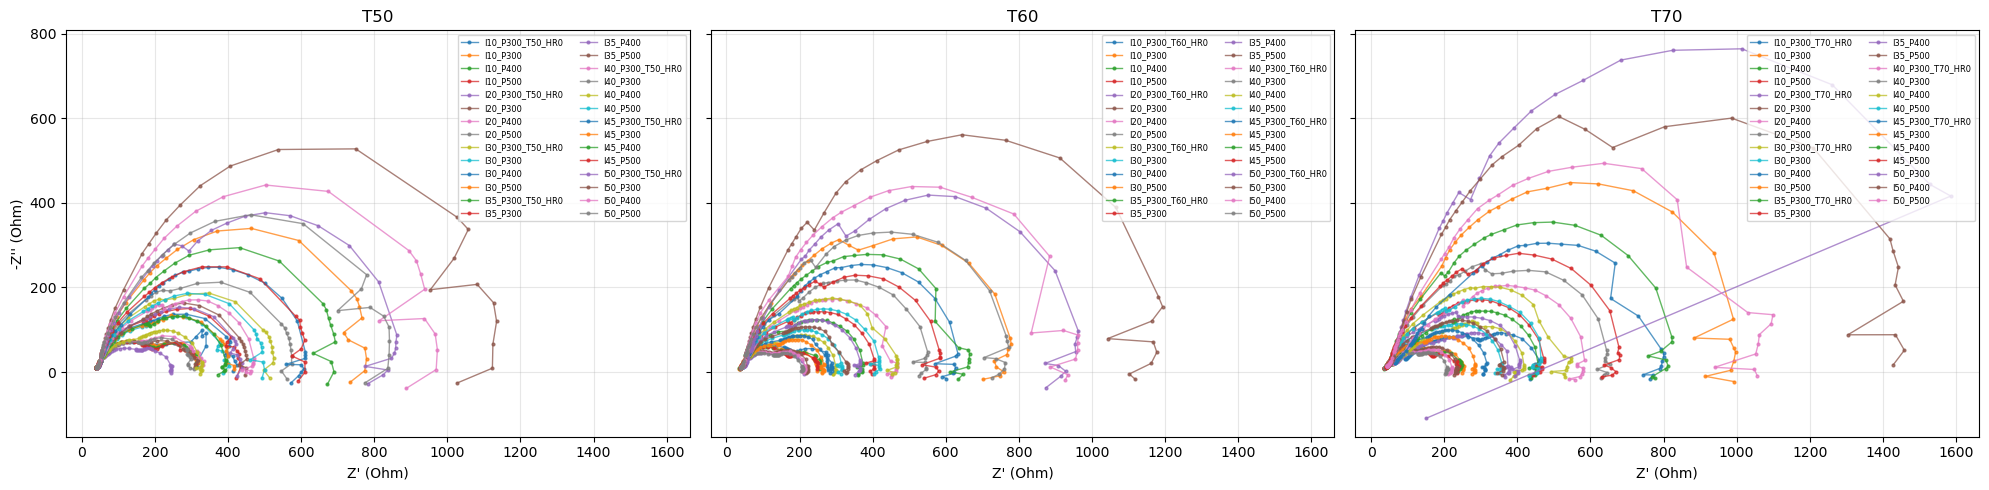

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
for ax, (temp, data_dict) in zip(axes, im_data_by_temp.items()):
    for name in sorted(data_dict):
        d = data_dict[name]
        label = name.replace(f"_{temp}_HR50", "")
        ax.plot(d.iloc[:, 4], -d.iloc[:, 5], marker="o", ms=2, lw=1, alpha=0.75, label=label)
    ax.set_title(temp)
    ax.set_xlabel("Z' (Ohm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, ncol=2)

axes[0].set_ylabel("-Z'' (Ohm)")
plt.tight_layout()
plt.show()

From T50, it is seen that the nyquist diagrams are in three clusters: 
- I10, 20: the mass transfer arc has similar size as the charge transfer one. it is possible that it is in pure vapor environment.
- I30, 35: the mass transfer arc is much bigger while the impact of pressure is not monotonous. For instance, at 35 A, it seems that the arc becomes bigger when increasing pressure. It is possible that it is in mixed liquid and vapor environment in CL and no big amount of liquid water in GDL. Actually, at this region, the high pressure could promote the liquid water appearance: if we don't change water mole fraction, higher pressure will cause higher vapor pressure and then touch the water condensation threshold. We need to verify the impact of pressure at this region. 
- I40, 45, 50: it is clear that 

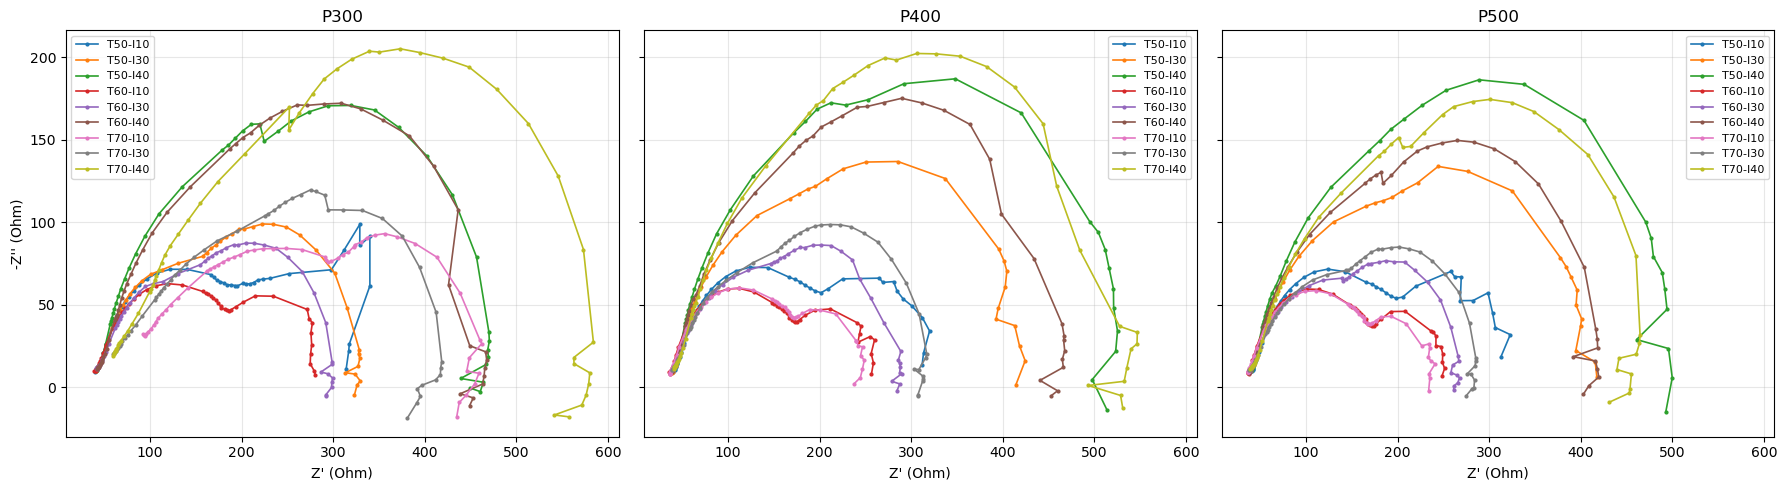

In [5]:
pressures = [300, 400, 500]
currents = [10, 30, 40]

if "im_data_by_temp" not in globals():
    import re
    files = {"T50": "Synth_Spectros_T50_N1.xlsx", "T60": "Synth_Spectros_T60_N1.xlsx", "T70": "Synth_Spectros_T70_N1.xlsx"}
    pattern = r"^I\d+_P\d+_T\d+_HR\d+$"
    im_data_by_temp = {
        t: {n: pd.read_excel(p, sheet_name=n) for n in pd.ExcelFile(p).sheet_names if re.match(pattern, n)}
        for t, p in files.items()
    }

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, p in zip(axes, pressures):
    for temp, data_dict in im_data_by_temp.items():
        for i in currents:
            key_prefix = f"I{i}_P{p}_{temp}_"
            matches = [n for n in data_dict if n.startswith(key_prefix)]
            if not matches:
                continue
            d = data_dict[sorted(matches)[0]]
            ax.plot(d.iloc[:, 4], -d.iloc[:, 5], marker="o", ms=2, lw=1.2, label=f"{temp}-I{i}")
    ax.set_title(f"P{p}")
    ax.set_xlabel("Z' (Ohm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("-Z'' (Ohm)")
plt.tight_layout()
plt.show()

Very interesting plots:
- in low current region (20A), it seems that the high temperature promotes mass transfer firstly (it is also possible that this actually promotes the charge transfer while mass transfer was kept at the same level), and then gives a negative impact (this could be linked to the water in the inlet water). The transition could be linked to the liquid water appearance. High pressure tends to keep the positive impact. 
- at high current region (40A), the high temperature gives progressively negative impact on mass transfer. This is linked to the generation of liquid water. Again, the high pressure will tend to maintain the positive impact as much as possible. But between 60 and 70 degrees, the pressure increase has not yet completely erase the impact. 

HRLOW sheets: ['I20_P300_T50_HRLOW_TBH2_20', 'I20_P300_T50_HRLOW_TBH2_40', 'I20_P300_T50_HRLOW_TBH2_65']


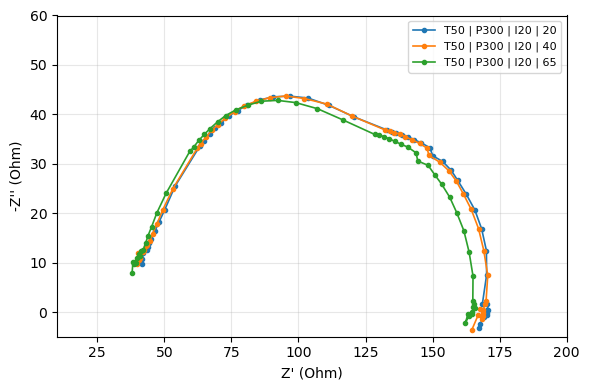

In [16]:

t50_path = files["T50"]
hrlow_sheets = [s for s in pd.ExcelFile(t50_path).sheet_names if "HRLOW" in s]
print("HRLOW sheets:", hrlow_sheets)

fig, ax = plt.subplots(figsize=(6, 4))
for sheet in sorted(hrlow_sheets):
    label_I = sheet.split("_")[0]
    label_P = sheet.split("_")[1]
    label_T = sheet.split("_")[2]
    label_HRC = sheet.split("_")[5]
    d = pd.read_excel(t50_path, sheet_name=sheet)
    ax.plot(d.iloc[:, 4], -d.iloc[:, 5], marker="o", ms=3, lw=1.2, label=f"{label_T} | {label_P} | {label_I} | {label_HRC}")

ax.set_xlabel("Z' (Ohm)")
ax.set_ylabel("-Z'' (Ohm)")
ax.set_xlim(10,200)
ax.set_ylim(-5,60)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


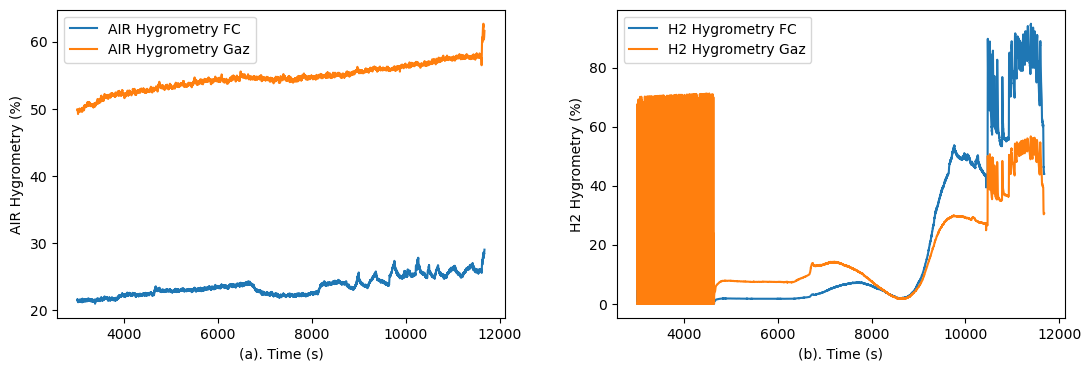

In [7]:
# High cathode stoichiometry and gradual humidification at the anode
i_start = 3000
i_end = -1
# High cathode stoichiometry and gradual humidification at the anode
pola_data_Sc = pd.read_excel("REC_24022026_142125.xlsx")
fig, axes = plt.subplots(figsize=(13, 4), ncols=2, nrows=1)
fig.subplots_adjust(wspace=0.25)
axes[0].plot(pola_data_Sc["HR_AIR_FC"][i_start:i_end], label="AIR Hygrometry FC")
axes[0].plot(pola_data_Sc["HR_AIR_Gaz"][i_start:i_end], label="AIR Hygrometry Gaz")
axes[0].set_ylabel("AIR Hygrometry (%)")
axes[0].set_xlabel("(a). Time (s)")
axes[0].legend()
axes[1].plot(pola_data_Sc["HR_H2_FC"][i_start:i_end], label="H2 Hygrometry FC")
axes[1].plot(pola_data_Sc["HR_H2_Gaz"][i_start:i_end], label="H2 Hygrometry Gaz")
axes[1].set_xlabel("(b). Time (s)")
axes[1].set_ylabel("H2 Hygrometry (%)")
axes[1].legend(loc="upper left")

(0.0, 100.0)

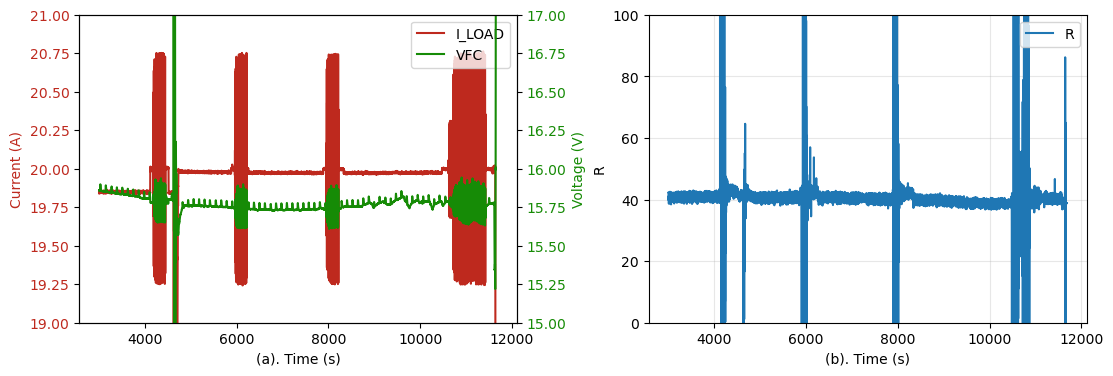

In [8]:
# High cathode stoichiometry and gradual humidification at the anode
i_start = 3000
i_end = -1
pola_data_Sc = pd.read_excel("REC_24022026_142125.xlsx")

fig, axes = plt.subplots(figsize=(13, 4), ncols=2, nrows=1)
fig.subplots_adjust(wspace=0.3)

# Left subplot: I_LOAD and VFC vs time
line_current, = axes[0].plot(pola_data_Sc["I_LOAD"][i_start:i_end], color="#be291e", label="I_LOAD")
axes[0].set_xlabel("(a). Time (s)")
axes[0].set_ylabel("Current (A)", color="#be291e")
axes[0].tick_params(axis="y", labelcolor="#be291e")
axes[0].set_ylim(19, 21)

ax2 = axes[0].twinx()
line_voltage, = ax2.plot(pola_data_Sc["VFC"][i_start:i_end], color="#168b06", label="VFC")
ax2.set_ylabel("Voltage (V)", color="#168b06")
ax2.tick_params(axis="y", labelcolor="#168b06")
ax2.set_ylim(15, 17)

axes[0].legend(handles=[line_current, line_voltage], loc="upper right")

# Right subplot: R vs time
axes[1].plot(pola_data_Sc["R"][i_start:i_end], color="#1f77b4", label="R")
axes[1].set_xlabel("(b). Time (s)")
axes[1].set_ylabel("R")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0,100)

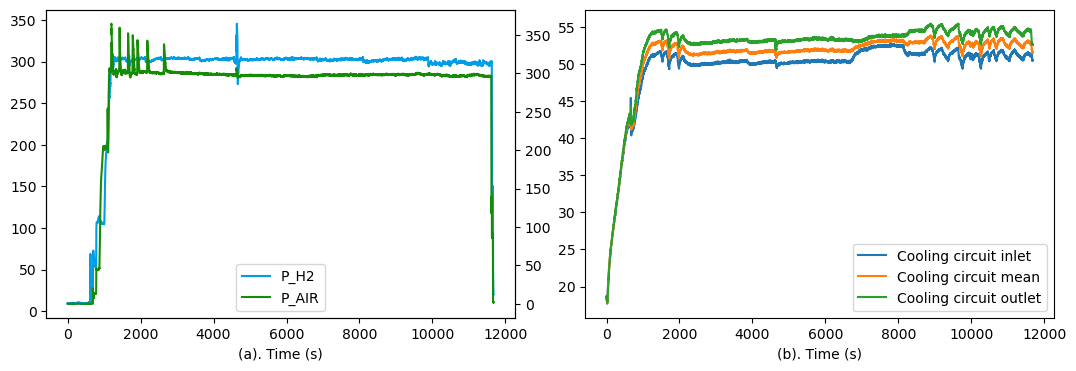

In [9]:
# High cathode stoichiometry and gradual humidification at the anode
i_start = 0
i_end = -1
# High cathode stoichiometry and gradual humidification at the anode
pola_data_Sc = pd.read_excel("REC_24022026_142125.xlsx")
fig, axes = plt.subplots(figsize=(13, 4), ncols=2, nrows=1)
fig.subplots_adjust(wspace=0.15)
line_P_H2, = axes[0].plot(pola_data_Sc["P_H2"][i_start:i_end], color="#009ee7", label="P_H2")
axes[0].set_xlabel("(a). Time (s)")
ax2 = axes[0].twinx()
line_P_AIR, = ax2.plot(pola_data_Sc["P_AIR"][i_start:i_end], color="#168b06", label="P_AIR")
axes[0].legend(handles=[ line_P_H2, line_P_AIR])
axes[1].plot(pola_data_Sc["T_H2O_IN"][i_start:i_end], label="Cooling circuit inlet")
axes[1].plot(pola_data_Sc["T_H2O_MEAN"][i_start:i_end], label="Cooling circuit mean")
axes[1].plot(pola_data_Sc["T_H2O_OUT"][i_start:i_end], label="Cooling circuit outlet")
axes[1].set_xlabel("(b). Time (s)")
axes[1].legend(loc="lower right")

HRK20 sheets: ['I45_P300_T70_HR50', 'I45_P300_T70_HR0']


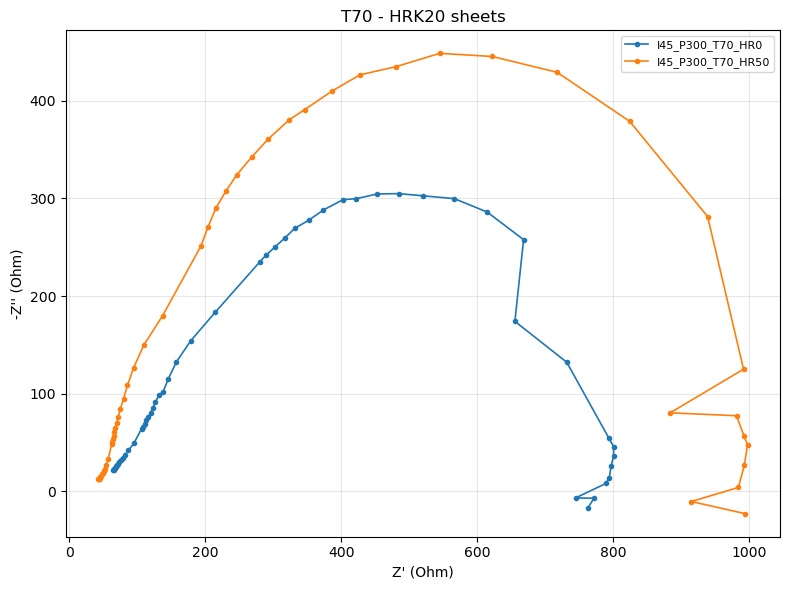

In [20]:
t70_path = files["T70"]
hrk20_sheets = [s for s in pd.ExcelFile(t70_path).sheet_names if ("P300" in s and "45" in s)]
print("HRK20 sheets:", hrk20_sheets)

fig, ax = plt.subplots(figsize=(8, 6))
for sheet in sorted(hrk20_sheets):
    d = pd.read_excel(t70_path, sheet_name=sheet)
    ax.plot(d.iloc[:, 4], -d.iloc[:, 5], marker="o", ms=3, lw=1.2, label=sheet)

ax.set_xlabel("Z' (Ohm)")
ax.set_ylabel("-Z'' (Ohm)")
ax.set_title("T70 - HRK20 sheets")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [17]:
pd.ExcelFile(t70_path).sheet_names

['I10_P300_T70_HR50',
 'I10_P400_T70_HR50',
 'I10_P500_T70_HR50',
 'I20_P300_T70_HR50',
 'I20_P400_T70_HR50',
 'I20_P500_T70_HR50',
 'I30_P300_T70_HR50',
 'I30_P400_T70_HR50',
 'I30_P500_T70_HR50',
 'I35_P300_T70_HR50',
 'I35_P400_T70_HR50',
 'I35_P500_T70_HR50',
 'I40_P300_T70_HR50',
 'I40_P400_T70_HR50',
 'I40_P500_T70_HR50',
 'I45_P300_T70_HR50',
 'I45_P400_T70_HR50',
 'I45_P500_T70_HR50',
 'I50_P300_T70_HR50',
 'I50_P400_T70_HR50',
 'I50_P500_T70_HR50',
 'I50_P500_T70_HRK20',
 'I10_P300_T70_HR0',
 'I20_P300_T70_HR0',
 'I30_P300_T70_HR0',
 'I35_P300_T70_HR0',
 'I40_P300_T70_HR0',
 'I45_P300_T70_HR0',
 'SYNTH',
 'TRACES']